In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [3]:
tf.__version__

'2.18.0'

In [4]:
mnist = tf.keras.datasets.mnist

In [5]:
(x_train, y_train), (x_test, y_test) =  mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
x_train.shape

(60000, 28, 28)

In [7]:
y_train.shape

(60000,)

In [8]:
x_test.shape

(10000, 28, 28)

In [9]:
y_test.shape

(10000,)

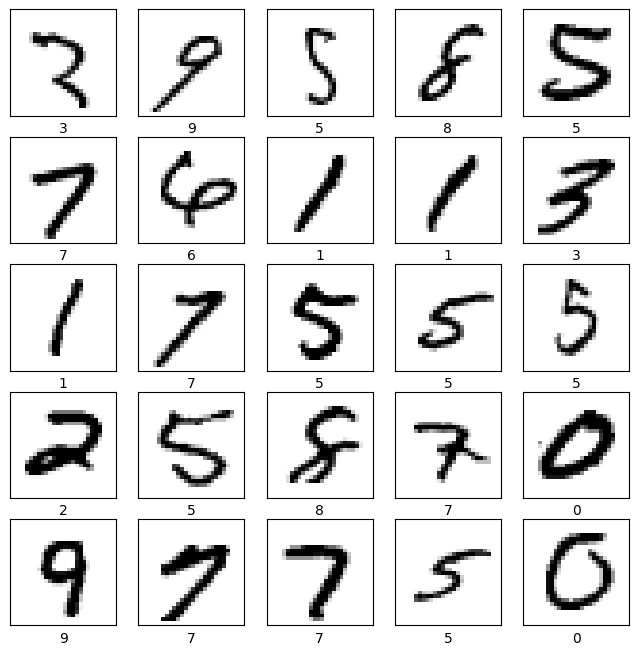

In [63]:
plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i + 500], cmap=plt.cm.binary)
    plt.xlabel(y_train[i + 500])
# plt.tight_layout()
plt.show()

In [11]:
x_train.min(), x_train.max()

(np.uint8(0), np.uint8(255))

In [91]:
x_train, x_test = x_train / 255.0, x_test / 255.0

In [156]:
model = tf.keras.models.Sequential([
  tf.keras.layers.InputLayer(input_shape=(28, 28)),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu', name='first_linear_layer', trainable=False), #wx + b
  # tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax', name='outputlayer', trainable=False)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [158]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.InputLayer(input_shape=(28, 28)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu', name='first_linear_layer', trainable=False))
model.add(tf.keras.layers.Dense(10, activation='softmax', name='outputlayer', trainable=False))

In [ ]:
i = tf.keras.layers.InputLayer(input_shape=(28, 28))
x = tf.keras.layers.Flatten()(i)
x = tf.keras.layers.Dense(128, activation='relu', name='first_linear_layer', trainable=False)(x)
x = tf.keras.layers.Dense(10, activation='softmax', name='outputlayer', trainable=False)(x)
model = tf.keras.Model(inputs=i, outputs=x)

In [152]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [153]:
y_train_one_hot = tf.one_hot(y_train, 10)
y_test_one_hot = tf.one_hot(y_test, 10)

In [154]:
history = model.fit(x_train, y_train_one_hot, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1584 - loss: 2.3026 - val_accuracy: 0.1487 - val_loss: 2.3026
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1540 - loss: 2.3026 - val_accuracy: 0.1487 - val_loss: 2.3026
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1627 - loss: 2.3026 - val_accuracy: 0.1487 - val_loss: 2.3026
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1514 - loss: 2.3026 - val_accuracy: 0.1487 - val_loss: 2.3026
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1590 - loss: 2.3026 - val_accuracy: 0.1487 - val_loss: 2.3026


In [42]:
history.history

{'accuracy': [0.9942499995231628,
  0.9941666722297668,
  0.9940624833106995,
  0.9937499761581421,
  0.9940000176429749],
 'loss': [0.01749323680996895,
  0.016479164361953735,
  0.017285874113440514,
  0.018586553633213043,
  0.017542023211717606],
 'val_accuracy': [0.9939166903495789,
  0.9917500019073486,
  0.9918333292007446,
  0.9922500252723694,
  0.9926666617393494],
 'val_loss': [0.0213319119066,
  0.023997636511921883,
  0.0274240393191576,
  0.025705302134156227,
  0.023738589137792587]}

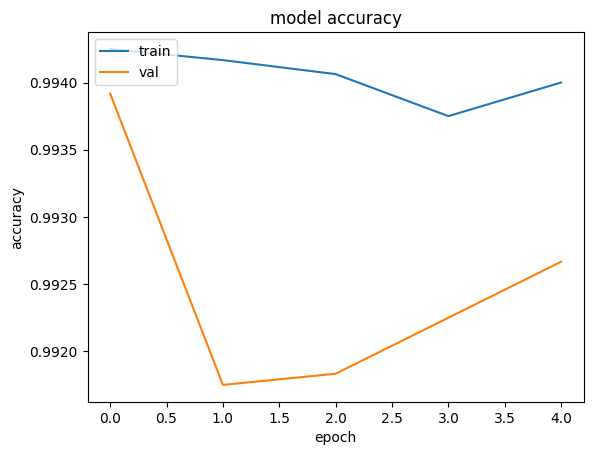

In [49]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

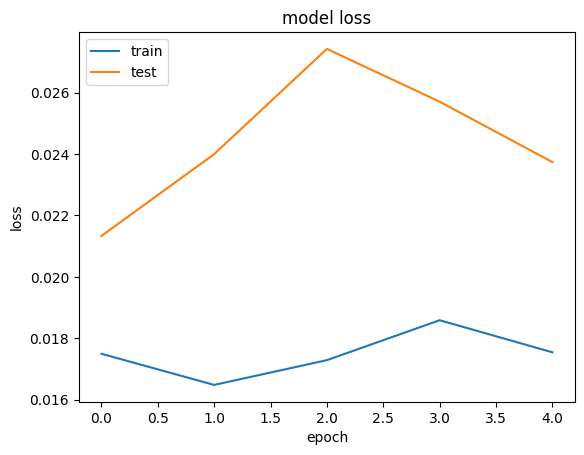

In [48]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [51]:
model.evaluate(x_test, y_test_one_hot, batch_size=64)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9786 - loss: 0.1084


[0.09327033162117004, 0.9825999736785889]

In [72]:
predictions = model.predict(x_test[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


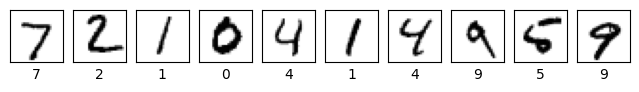

In [73]:
plt.figure(figsize=(8,8))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
    plt.xlabel(y_test[i])
# plt.tight_layout()
plt.show()

In [74]:
tf.argmax(predictions, axis=1)

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])>

In [117]:
weights = model.get_weights()

In [122]:
weights[3].shape

(10,)

In [125]:
sum = 0
sum += weights[0].shape[0] * weights[0].shape[1]
sum += weights[1].shape[0]
sum += weights[2].shape[0] * weights[2].shape[1]
sum += weights[3].shape[0]
print(sum)

101770


In [149]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ first_linear_layer (Dense)      │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputlayer (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,352 (407.63 KB)

 Trainable params: 1,290 (5.04 KB)

 Non-trainable params: 100,480 (392.50 KB)

 Optimizer params: 2,582 (10.09 KB)

In [150]:
model.trainable_variables

[<Variable path=sequential_5/sequential_7/outputlayer/kernel, shape=(128, 10), dtype=float32, value=[[ 0.17346127  0.05761377  0.10697456 ... -0.14335404  0.20044976
    0.07804101]
  [ 0.1346357   0.125985   -0.06899343 ...  0.1702736  -0.10618336
   -0.19694108]
  [-0.10019238  0.10516649  0.03917914 ... -0.04962534 -0.05040577
    0.01902055]
  ...
  [ 0.06873792 -0.1013992   0.02465859 ...  0.00122792 -0.20239504
   -0.1679351 ]
  [-0.02033215 -0.19702618 -0.1665207  ...  0.12736315  0.02912336
    0.15165365]
  [ 0.1615417   0.00687706 -0.1840352  ... -0.09818415  0.12953405
   -0.0014486 ]]>,
 <Variable path=sequential_5/sequential_7/outputlayer/bias, shape=(10,), dtype=float32, value=[-0.01589105  0.12664786 -0.00599569  0.01526539 -0.02117124 -0.10622921
  -0.00560615  0.02504745 -0.04453878  0.00551648]>]

In [144]:
model.layers[1].get_weights()

[array([[-0.04015457,  0.04200341, -0.03905027, ...,  0.00065524,
         -0.04405346,  0.05658663],
        [ 0.05098773, -0.01049265,  0.06670631, ...,  0.02970148,
         -0.07891912,  0.06157423],
        [-0.01115193, -0.07353421,  0.03664635, ..., -0.00190573,
         -0.0729028 ,  0.01125706],
        ...,
        [-0.07939478, -0.03536254,  0.04329842, ...,  0.06641457,
         -0.03464876,  0.01180002],
        [ 0.04155339, -0.05352426, -0.06774756, ..., -0.00638574,
         -0.06308386, -0.01725286],
        [ 0.07694209,  0.0616511 , -0.05439887, ..., -0.00873762,
          0.07950888,  0.0674823 ]], dtype=float32),
 array([-0.00368383, -0.00600497, -0.00360277, -0.00495284, -0.00600454,
        -0.00597185, -0.00600426, -0.005959  , -0.00294361, -0.00600485,
        -0.00277479, -0.00733239, -0.00600447, -0.00308037, -0.00600357,
        -0.00217306, -0.00600437, -0.00600368, -0.00026567, -0.007739  ,
        -0.00600296, -0.00517051, -0.00383358,  0.04728016, -0.006